Loaded with encoding=gbk

[计数检查] 原始细胞数：
CD4T 总数 : 6087
CD8T 总数 : 25799
M1   总数 : 14750

[各时期有效 n]（能找到最近 M1 的 CD4T / CD8T）：
CD4T→M1 : {'T005': 825, 'T006': 774, 'T001': 889, 'T002': 2112, 'T004': 289}
CD8T→M1 : {'T005': 4907, 'T006': 2107, 'T001': 4002, 'T002': 8849, 'T004': 716}

Saved files:
C:/Users/Li Chujia/ipynb/typex\Fig3b_stagewise_CDF_CD4_vs_CD8_to_nearest_M1.png
C:/Users/Li Chujia/ipynb/typex\Fig3b_stagewise_CDF_CD4_vs_CD8_to_nearest_M1.pdf


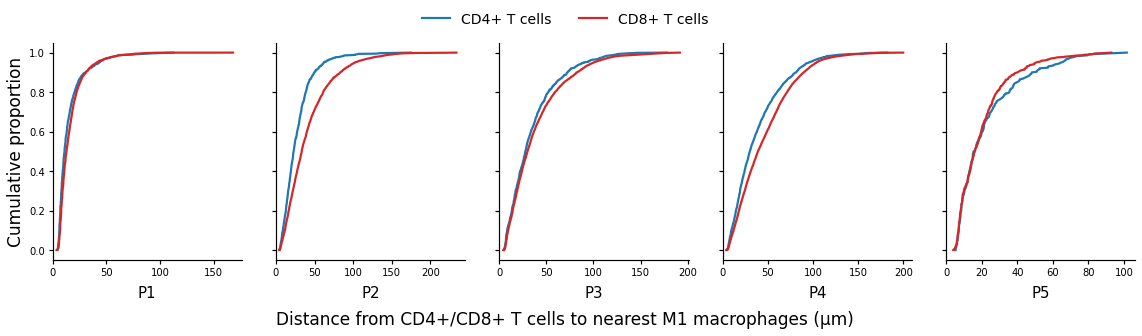


DONE.


In [3]:
# -*- coding: utf-8 -*-
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# =========================
# 基本配置
# =========================
CSV_PATH      = r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv"
COL_STAGE     = "标签"        # T001/T002/T004/T005/T006
COL_SLICE     = "子标签"      # ROIxxx
COL_CELLTYPE  = "cell_type"
COL_IL1B      = "IL_1b"
COL_TNFA      = "TNFa"

# 原始顺序
STAGES_ORDER = ["T001", "T002", "T004", "T005", "T006"]

# 作图顺序：P1 → P5
PLOT_STAGE_ORDER = ["T005", "T006", "T001", "T002", "T004"]
STAGE_TO_P = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5",
}

# =========================
# 输出保存设置
# =========================
OUT_DIR = r"C:/Users/Li Chujia/ipynb/typex"
OUT_BASENAME = "Fig3b_stagewise_CDF_CD4_vs_CD8_to_nearest_M1"

SAVE_PNG = True
SAVE_PDF = True
DPI = 600
SHOW_FIG = True

# =========================
# 图形参数（都可手动调）
# =========================
FIG_W = 16
FIG_H = 5.2

TOP_MARGIN = 0.82
BOTTOM_MARGIN = 0.24
LEFT_MARGIN = 0.055
RIGHT_MARGIN = 0.995
WSPACE = 0.18

AXIS_LW = 1.2
LINE_W = 2.2

# 字号
PANEL_STAGE_SIZE   = 15   # 每个子图下方 P1/P2/P3/P4/P5 的字号
SHARED_X_LABEL_SIZE = 17  # 整张图共享大横坐标字号
Y_LABEL_SIZE       = 17
X_TICK_SIZE        = 10
Y_TICK_SIZE        = 10
LEGEND_SIZE        = 14   # 图例字体放大

# 只留一个总图例
LEGEND_Y = 0.935          # 往下调一点，更靠近主图
LEGEND_NCOL = 2

# 共享大横坐标位置
SHARED_XLABEL_Y = 0.08

# 每个 panel 下方 P1/P2... 与坐标轴距离
PANEL_STAGE_PAD = 8

# 是否五个图共用 y 轴
SHARE_Y = True

# 如果想限制 x 轴上限，可改成数字；不限制就设 None
X_MAX = None

# =========================
# 颜色设置
# =========================
CD4_COLOR = "#1f77b4"   # blue
CD8_COLOR = "#d62728"   # red

# =========================
# 坐标列候选（自动识别）
# =========================
CAND_X_COLS = ["X", "x", "X_position", "Xpos", "XPos", "CenterX", "center_x", "X_um", "X (um)"]
CAND_Y_COLS = ["Y", "y", "Y_position", "Ypos", "YPos", "CenterY", "center_y", "Y_um", "Y (um)"]

# =========================
# ROI 过滤（按你原始代码逻辑）
# 当前仅对 T004 保留指定 ROI
# =========================
STAGE_SLICE_WHITELIST = {
    "T004": {"ROI008", "ROI009", "ROI010"}
}

# =========================
# 小工具
# =========================
def find_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def normalize_celltype(x: str) -> str:
    """把各种写法统一成 CD4T / CD8T / M1 等"""
    if pd.isna(x):
        return ""
    s = str(x).strip().upper()

    cd4t_aliases = {"CD4_T", "CD4 T", "CD4+T", "CD4T", "CD4T CELL", "CD4T_CELL"}
    cd8t_aliases = {"CD8_T", "CD8 T", "CD8+T", "CD8T", "CD8T CELL", "CD8T_CELL"}
    m1_aliases   = {"M1", "M1_MACROPHAGE", "M1-LIKE", "HUBM1", "M1 LIKE", "M1_MAC"}

    if s in cd4t_aliases:
        return "CD4T"
    if s in cd8t_aliases:
        return "CD8T"
    if s in m1_aliases:
        return "M1"

    s2 = re.sub(r"[^A-Z0-9]", "", s)
    if "CD4" in s2 and "T" in s2:
        return "CD4T"
    if "CD8" in s2 and "T" in s2:
        return "CD8T"
    if s2.startswith("M1"):
        return "M1"
    return s2

def stepwise_cdf(d):
    """给定一组距离 d，返回阶梯 CDF 所需的 (x, y)"""
    if len(d) == 0:
        return np.array([]), np.array([])
    d = np.sort(np.asarray(d, float))
    y = np.arange(1, len(d) + 1) / len(d)
    x = np.concatenate([[d[0]], d])
    y = np.concatenate([[0.0], y])
    return x, y

def set_jcc_style_axes(ax, show_ylabels=True):
    """只保留左/下边框，不要上/右边框，不要网格"""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(AXIS_LW)
    ax.spines["bottom"].set_linewidth(AXIS_LW)

    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")

    ax.tick_params(
        axis="x",
        which="both",
        direction="out",
        labelsize=X_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )
    ax.tick_params(
        axis="y",
        which="both",
        direction="out",
        labelsize=Y_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )

    if not show_ylabels:
        ax.tick_params(axis="y", labelleft=False)

    ax.grid(False)

def save_figure(fig, out_dir, out_basename, save_png=True, save_pdf=True, dpi=600):
    os.makedirs(out_dir, exist_ok=True)
    saved_files = []

    if save_png:
        png_path = os.path.join(out_dir, f"{out_basename}.png")
        fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        saved_files.append(png_path)

    if save_pdf:
        pdf_path = os.path.join(out_dir, f"{out_basename}.pdf")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        saved_files.append(pdf_path)

    return saved_files

def apply_stage_slice_filter(sub_stage, stg, col_slice, whitelist_dict):
    keep_set = whitelist_dict.get(stg, None)
    if keep_set is None:
        return sub_stage
    keep_set = set(keep_set)
    return sub_stage[sub_stage[col_slice].isin(keep_set)]

def build_stage_to_dists_custom_hub(df, target_mask, hub_mask,
                                    stages=PLOT_STAGE_ORDER,
                                    col_stage=COL_STAGE,
                                    col_slice=COL_SLICE,
                                    whitelist_dict=None):
    """
    按时期×切片计算 target → 最近 hub 的最小距离；
    返回 {stage: np.array}
    """
    out = {}
    whitelist_dict = whitelist_dict or {}

    for stg in stages:
        sub_stage = df[df[col_stage].astype(str).str.strip() == stg]
        if sub_stage.empty:
            continue

        sub_stage = apply_stage_slice_filter(sub_stage, stg, col_slice, whitelist_dict)

        dists_all = []
        for _, sub in sub_stage.groupby(col_slice):
            target_xy = sub.loc[target_mask.loc[sub.index], [col_x, col_y]].dropna().to_numpy()
            hub_xy    = sub.loc[hub_mask.loc[sub.index],    [col_x, col_y]].dropna().to_numpy()

            if len(target_xy) == 0 or len(hub_xy) == 0:
                continue

            d, _ = cKDTree(hub_xy).query(target_xy, k=1, workers=-1)
            if len(d) > 0:
                dists_all.append(d)

        if dists_all:
            out[stg] = np.concatenate(dists_all, axis=0)

    return out

# =========================
# 读取与预处理
# =========================
df = None
for enc in ["utf-8", "gbk", "latin1", "gb18030", "utf-8-sig"]:
    try:
        df = pd.read_csv(CSV_PATH, encoding=enc)
        print(f"Loaded with encoding={enc}")
        break
    except Exception:
        pass

if df is None:
    raise RuntimeError(f"无法读取：{CSV_PATH}")

for c in [COL_STAGE, COL_SLICE, COL_CELLTYPE]:
    if c not in df.columns:
        raise KeyError(f"缺少列：{c}")

col_x = find_first_col(df, CAND_X_COLS)
col_y = find_first_col(df, CAND_Y_COLS)
if col_x is None or col_y is None:
    raise KeyError(f"未找到坐标列。X候选={CAND_X_COLS}；Y候选={CAND_Y_COLS}")

df[col_x] = pd.to_numeric(df[col_x], errors="coerce")
df[col_y] = pd.to_numeric(df[col_y], errors="coerce")
df = df.dropna(subset=[col_x, col_y]).copy()

df["_ct_norm"] = df[COL_CELLTYPE].astype(str).map(normalize_celltype)

# =========================
# 定义 CD4 / CD8 / M1
# =========================
mask_cd4 = (df["_ct_norm"] == "CD4T")
mask_cd8 = (df["_ct_norm"] == "CD8T")
hub_m1   = (df["_ct_norm"] == "M1")

print("\n[计数检查] 原始细胞数：")
print("CD4T 总数 :", int(mask_cd4.sum()))
print("CD8T 总数 :", int(mask_cd8.sum()))
print("M1   总数 :", int(hub_m1.sum()))

# =========================
# 计算各时期距离分布
# =========================
stage_to_dists_cd4 = build_stage_to_dists_custom_hub(
    df, mask_cd4, hub_m1,
    stages=PLOT_STAGE_ORDER,
    whitelist_dict=STAGE_SLICE_WHITELIST
)
stage_to_dists_cd8 = build_stage_to_dists_custom_hub(
    df, mask_cd8, hub_m1,
    stages=PLOT_STAGE_ORDER,
    whitelist_dict=STAGE_SLICE_WHITELIST
)

print("\n[各时期有效 n]（能找到最近 M1 的 CD4T / CD8T）：")
print("CD4T→M1 :", {s: len(stage_to_dists_cd4[s]) for s in stage_to_dists_cd4})
print("CD8T→M1 :", {s: len(stage_to_dists_cd8[s]) for s in stage_to_dists_cd8})

# =========================
# 作图：5个时期横向排版
# 每个 panel 内比较 CD4T vs CD8T
# 每个子图下方仅保留 P1/P2/P3/P4/P5
# 整张图共享一个横坐标说明
# =========================
fig, axes = plt.subplots(1, 5, figsize=(FIG_W, FIG_H), sharey=SHARE_Y)

legend_handles = []
legend_labels = []

for i, stg in enumerate(PLOT_STAGE_ORDER):
    ax = axes[i]

    d_cd4 = stage_to_dists_cd4.get(stg, np.array([]))
    d_cd8 = stage_to_dists_cd8.get(stg, np.array([]))

    xs_cd4, ys_cd4 = stepwise_cdf(d_cd4)
    xs_cd8, ys_cd8 = stepwise_cdf(d_cd8)

    if len(xs_cd4) > 0:
        line_cd4, = ax.plot(
            xs_cd4, ys_cd4,
            color=CD4_COLOR,
            linewidth=LINE_W,
            label="CD4+ T cells"
        )
        if i == 0:
            legend_handles.append(line_cd4)
            legend_labels.append("CD4+ T cells")

    if len(xs_cd8) > 0:
        line_cd8, = ax.plot(
            xs_cd8, ys_cd8,
            color=CD8_COLOR,
            linewidth=LINE_W,
            label="CD8+ T cells"
        )
        if i == 0:
            legend_handles.append(line_cd8)
            legend_labels.append("CD8+ T cells")

    # 每个子图下方只保留时期标签
    ax.set_xlabel(
        STAGE_TO_P[stg],
        fontsize=PANEL_STAGE_SIZE,
        labelpad=PANEL_STAGE_PAD
    )

    # 只在最左侧保留 y 轴文字
    if i == 0:
        ax.set_ylabel("Cumulative proportion", fontsize=Y_LABEL_SIZE)
        set_jcc_style_axes(ax, show_ylabels=True)
    else:
        set_jcc_style_axes(ax, show_ylabels=False)

    # x 轴范围
    ax.set_xlim(left=0)
    if X_MAX is not None:
        ax.set_xlim(0, X_MAX)

# 整张图共享一个大横坐标说明
fig.text(
    0.5, SHARED_XLABEL_Y,
    "Distance from CD4+/CD8+ T cells to nearest M1 macrophages (μm)",
    ha="center", va="center",
    fontsize=SHARED_X_LABEL_SIZE
)

# 只保留一个总图例，字体更大，并下移靠近主图
fig.legend(
    legend_handles, legend_labels,
    frameon=False,
    fontsize=LEGEND_SIZE,
    loc="upper center",
    bbox_to_anchor=(0.5, LEGEND_Y),
    ncol=LEGEND_NCOL
)

plt.subplots_adjust(
    left=LEFT_MARGIN,
    right=RIGHT_MARGIN,
    bottom=BOTTOM_MARGIN,
    top=TOP_MARGIN,
    wspace=WSPACE
)

# =========================
# 保存输出
# =========================
saved_files = save_figure(
    fig,
    out_dir=OUT_DIR,
    out_basename=OUT_BASENAME,
    save_png=SAVE_PNG,
    save_pdf=SAVE_PDF,
    dpi=DPI
)

print("\nSaved files:")
for f in saved_files:
    print(f)

if SHOW_FIG:
    plt.show()
else:
    plt.close(fig)

print("\nDONE.")